# 06 - Naive Baseline Karşılaştırması

Bu notebook'ta, geliştirilen modellerin gerçek bir katkı sağlayıp sağlamadığını test etmek için **naive baseline** referans olarak eklenmektedir.

**Naive baseline**: `y_pred[t] = y[t-1]` — yani bir sonraki response_time değerinin, bir önceki değerle aynı olacağı varsayımı.

Bu yaklaşım hiçbir öğrenme içermez ve modellerin gerçekten neyi öğrendiğini test etmek için kullanılır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Veri Yükleme

In [2]:
df = pd.read_csv('../data/raw/request_level_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Diğer notebook'larla aynı sliding window ve split yapısı için
# Lag feature'lar ekleyip NaN'ları temizle (02b ile aynı veri yapısı)
for lag in [1, 2, 3]:
    df[f'response_time_lag_{lag}'] = df['response_time_ms'].shift(lag)
df['response_time_roll_mean_5']  = df['response_time_ms'].shift(1).rolling(5).mean()
df['response_time_roll_mean_10'] = df['response_time_ms'].shift(1).rolling(10).mean()
df['response_time_roll_std_5']   = df['response_time_ms'].shift(1).rolling(5).std()
df = df.dropna().reset_index(drop=True)

print(f'Veri boyutu: {df.shape}')

Veri boyutu: (29199, 20)


## Train-Test Split 

Diğer modellerle adil karşılaştırma için aynı test seti kullanılmaktadır.

In [3]:
WINDOW_SIZE = 10

# Sliding window sonrası split noktasını hesapla
n_samples = len(df) - WINDOW_SIZE
split = int(n_samples * 0.8)

# Test setindeki gerçek y değerleri
y_test = df['response_time_ms'].iloc[WINDOW_SIZE + split:].values

# Naive tahmin: y_pred[t] = y[t-1]
y_pred_naive = df['response_time_ms'].iloc[WINDOW_SIZE + split - 1 : -1].values

print(f'y_test boyutu:       {y_test.shape}')
print(f'y_pred_naive boyutu: {y_pred_naive.shape}')

# İlk birkaç değer kontrolü
print('\nİlk 5 gerçek değer: ', y_test[:5].round(1))
print('İlk 5 naive tahmin: ', y_pred_naive[:5].round(1))

y_test boyutu:       (5838,)
y_pred_naive boyutu: (5838,)

İlk 5 gerçek değer:  [123.1 149.6 136.7 133.  161.6]
İlk 5 naive tahmin:  [527.9 123.1 149.6 136.7 133. ]


## Naive Baseline Performansı

In [4]:
def evaluate(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R2':   round(r2_score(y_true, y_pred), 4)
    }

naive_results = evaluate(y_test, y_pred_naive, 'Naive (y[t-1])')
print(naive_results)

{'Model': 'Naive (y[t-1])', 'MAE': 97.21, 'RMSE': np.float64(202.21), 'R2': -0.0337}


## Tüm Modellerle Karşılaştırma

In [6]:
all_results = [
    naive_results,
    {'Model': 'LR (baseline)',   'MAE': 147.21, 'RMSE': 196.44, 'R2': 0.0242},
    {'Model': 'RF (baseline)',   'MAE': 146.37, 'RMSE': 196.56, 'R2': 0.0230},
    {'Model': 'LSTM (baseline)', 'MAE': 121.23, 'RMSE': 177.79, 'R2': 0.2008},
    {'Model': 'LR (enhanced)',   'MAE': 123.71, 'RMSE': 178.91, 'R2': 0.1908},
    {'Model': 'RF (enhanced)',   'MAE':  88.17, 'RMSE': 152.82, 'R2': 0.4096},
    {'Model': 'LSTM (enhanced)', 'MAE':  88.75, 'RMSE': 154.16, 'R2': 0.3992},
]

final_df = pd.DataFrame(all_results).set_index('Model')
print(final_df.to_string())
final_df

                    MAE    RMSE      R2
Model                                  
Naive (y[t-1])    97.21  202.21 -0.0337
LR (baseline)    147.21  196.44  0.0242
RF (baseline)    146.37  196.56  0.0230
LSTM (baseline)  121.23  177.79  0.2008
LR (enhanced)    123.71  178.91  0.1908
RF (enhanced)     88.17  152.82  0.4096
LSTM (enhanced)   88.75  154.16  0.3992


,MAE,RMSE,R2
Model,,,
Naive (y[t-1]),97.21,202.21,-0.0337
LR (baseline),147.21,196.44,0.0242
RF (baseline),146.37,196.56,0.0230
LSTM (baseline),121.23,177.79,0.2008
LR (enhanced),123.71,178.91,0.1908
RF (enhanced),88.17,152.82,0.4096
LSTM (enhanced),88.75,154.16,0.3992


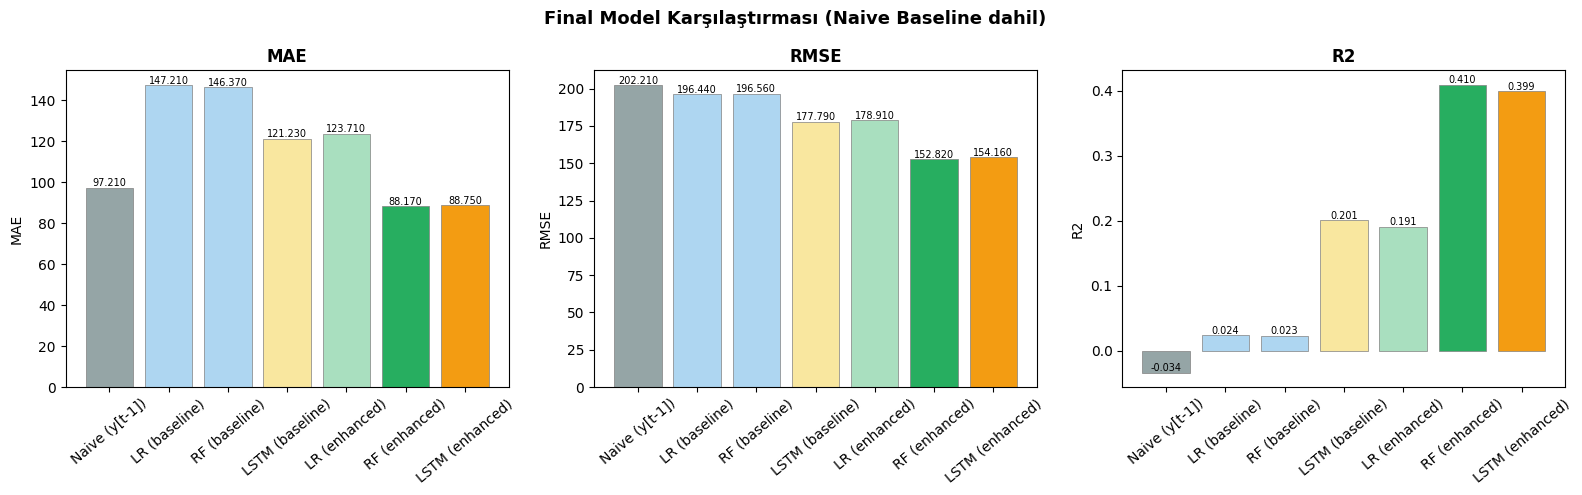

In [7]:
# Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']

color_map = {
    'Naive (y[t-1])':  '#95a5a6',
    'LR (baseline)':   '#aed6f1',
    'RF (baseline)':   '#aed6f1',
    'LSTM (baseline)': '#f9e79f',
    'LR (enhanced)':   '#a9dfbf',
    'RF (enhanced)':   '#27ae60',
    'LSTM (enhanced)': '#f39c12',
}

for ax, metric in zip(axes, metrics):
    vals = final_df[metric]
    colors = [color_map[m] for m in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='gray', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005 * max(vals.values),
                f'{val:.3f}', ha='center', fontsize=7)

plt.suptitle('Final Model Karşılaştırması (Naive Baseline dahil)', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/final_comparison_with_naive.png', dpi=150, bbox_inches='tight')
plt.show()

## Yorum

Naive baseline (y[t] = y[t-1]) sonuçları, geliştirilen modellerin değerlendirilmesi açısından kritik bulgular ortaya koymuştur:

**Naive baseline R² = -0.03 (negatif)** değeri üretmiştir. Bu, naive yaklaşımın ortalama tahmin etmekten bile kötü performans gösterdiği anlamına gelmektedir. MAE değerinin nispeten düşük (97.21) çıkması sistemin çoğunlukla stabil çalışmasından ve ardışık değerlerin benzer olmasından kaynaklanmaktadır. Ancak RMSE'nin tüm modeller arasında en yüksek (202.21) olması, naive yaklaşımın ani gecikme artışlarında (spike) ciddi tahmin hataları ürettiğini göstermektedir.

**Enhanced modellerin naive baseline'a göre performansı:**
- MAE: %9.3 iyileşme (97.21 → 88.17)
- RMSE: %24.4 iyileşme (202.21 → 152.82)
- R²: -0.03'ten 0.41'e — mutlak 0.44 puanlık artış

Bu sonuçlar, enhanced modellerin yalnızca bir önceki değeri ezberlemediğini, aynı zamanda sistem yükü, trafik yoğunluğu ve geçmiş performans trendleri arasındaki ilişkileri öğrendiğini kanıtlamaktadır. Özellikle RMSE'deki belirgin iyileşme, modellerin spike bölgelerinde naive yaklaşıma kıyasla çok daha başarılı olduğunu ortaya koymaktadır.

`response_time_lag_1` feature'ının en güçlü predictor (importance: 0.287) olarak tespit edilmesi, naive yaklaşımla tutarlıdır. Ancak enhanced modeller bu bilgiyi diğer feature'larla (endpoint türü, rolling istatistikler, trafik metrikleri) birleştirerek anlamlı bir performans artışı sağlamıştır.

In [8]:
# Sonuçları kaydet
final_df.to_csv('../data/final_comparison_with_naive.csv')
print('Kaydedildi: ../data/final_comparison_with_naive.csv')

Kaydedildi: ../data/final_comparison_with_naive.csv
